<h1>COIT12209 Assessment 2: Bike Rental Usage Analysis and Predictive Modelling</h1>

<h2>Final Submission Notebook by Kseniia Zaichenko (12264917) </h2>

## 1. Import Libraries

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Machine learning libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

## 2. Load Original Dataset

In [2]:
# Load the data
bike_data = pd.read_csv("bike_rental.csv")

# Preview the data
bike_data.head()

,date,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,count
0,1/01/2024,Summer,1,0,Cloudy,21.5,21.6,68.8,11.9,1156.0
1,2/01/2024,Summer,1,0,Clear,19.6,18.7,60.1,11.8,735.0
2,3/01/2024,Summer,1,0,Rain,22.2,24.3,84.5,15.7,1056.0
3,4/01/2024,Summer,1,0,Cloudy,25.0,NaN,73.1,18.4,1188.0
4,5/01/2024,Summer,1,0,Clear,20.1,20.5,66.4,4.9,930.0


## 3. Initial Data Inspection

### 3.1 Initial Shape, column names and data types

In [3]:
# Basic dataset inspection
print("Original dataset shape:", bike_data.shape)

print("\nColumn names:")
print(bike_data.columns)

print("\nData types:")
print(bike_data.dtypes)

Original dataset shape: (761, 10)

Column names:
Index(['date', 'season', 'holiday', 'workingday', 'weather', 'temp', 'atemp',
       'humidity', 'windspeed', 'count'],
      dtype='str')

Data types:
date              str
season            str
holiday         int64
workingday      int64
weather           str
temp          float64
atemp         float64
humidity      float64
windspeed     float64
count         float64
dtype: object


### 3.2 Missing Values and Duplicate Rows Checks

In [4]:
# Inspection for missing values and dublicate rows
print("\nMissing values:")
print(bike_data.isnull().sum())

print("\nDuplicate rows:")
print(bike_data.duplicated().sum())


Missing values:
date           0
season         0
holiday        0
workingday     0
weather        0
temp          26
atemp         26
humidity      26
windspeed     26
count         28
dtype: int64

Duplicate rows:
23


### 3.3 Expected Value Validation

In [5]:
# Validate categorical and binary columns against expected values

expected_values = {
    "season": ["Summer", "Autumn", "Winter", "Spring"],
    "weather": ["Clear", "Cloudy", "Rain", "Storm"],
    "holiday": [0, 1],
    "workingday": [0, 1]
}

validation_results = []

# Identification of spelling mistakes or unexpected values before cleaning
for column, valid_values in expected_values.items():
    unexpected_values = bike_data.loc[
        ~bike_data[column].isin(valid_values),
        column
    ].dropna().unique()

    unexpected_values = sorted(list(unexpected_values), key=str)

    validation_results.append({
        "Column": column,
        "Expected values": ", ".join(map(str, valid_values)),
        "Unexpected values": ", ".join(map(str, unexpected_values)) if unexpected_values else "None",
        "Number of unexpected rows": (~bike_data[column].isin(valid_values)).sum()
    })

validation_results = pd.DataFrame(validation_results)

display(validation_results)

,Column,Expected values,Unexpected values,Number of unexpected rows
0,season,"Summer, Autumn, Winter, Spring",Summr,1
1,weather,"Clear, Cloudy, Rain, Storm",Rainn,1
2,holiday,"0, 1",None,0
3,workingday,"0, 1",None,0


### 3.4 Initial Numerical Range Checks

In [6]:
# Initial numerical range checks to identify logically invalid or suspicious numerical values before cleaning

numeric_columns = ["temp", "atemp", "humidity", "windspeed", "count"]


invalid_humidity = bike_data[
    (bike_data["humidity"] < 0) | (bike_data["humidity"] > 100)
]

invalid_windspeed = bike_data[
    (bike_data["windspeed"] < 0) |
    (bike_data["windspeed"] > 100)
]

invalid_count = bike_data[
    bike_data["count"] < 0
]

suspicious_temp = bike_data[
    (bike_data["temp"] < -2) | (bike_data["temp"] > 46)
]

suspicious_atemp = bike_data[
    (bike_data["atemp"] < -5) | (bike_data["atemp"] > 50)
]

print("\nNumerical range diagnostic results:")
print("Invalid humidity values:", len(invalid_humidity))
print("Invalid windspeed values:", len(invalid_windspeed))
print("Invalid count values:", len(invalid_count))
print("Suspicious temp values:", len(suspicious_temp))
print("Suspicious atemp values:", len(suspicious_atemp))


Numerical range diagnostic results:
Invalid humidity values: 6
Invalid windspeed values: 0
Invalid count values: 2
Suspicious temp values: 6
Suspicious atemp values: 0


### 3.5 Count Outlier Diagnostic Check

In [7]:
# Diagnostic check for extreme count outliers using the IQR method

count_data = bike_data["count"].dropna() # Missing count values are ignored for this calculation

Q1 = count_data.quantile(0.25)
Q3 = count_data.quantile(0.75)
IQR = Q3 - Q1

count_lower_bound = max(0, Q1 - 1.5 * IQR)
count_upper_bound = Q3 + 1.5 * IQR

count_outliers = bike_data[
    (bike_data["count"] < count_lower_bound) |
    (bike_data["count"] > count_upper_bound)
]

print("Count outlier diagnostic results:")
print("Count lower bound:", round(count_lower_bound, 2))
print("Count upper bound:", round(count_upper_bound, 2))
print("Number of count outliers identified:", len(count_outliers))

if len(count_outliers) > 0:
    print("\nCount outliers preview:")
    display(count_outliers[["date", "season", "weather", "temp", "humidity", "windspeed", "count"]].head(20))

Count outlier diagnostic results:
Count lower bound: 0
Count upper bound: 1678.5
Number of count outliers identified: 6

Count outliers preview:


,date,season,weather,temp,humidity,windspeed,count
53,22/02/2024,Summer,Cloudy,31.9,77.8,10.0,-50.0
232,12/08/2024,Winter,Rain,17.7,47.4,7.2,50000.0
387,7/01/2025,Summer,Clear,22.1,66.7,9.5,-100.0
454,11/03/2025,Autumn,Clear,27.8,69.9,4.3,20000.0
488,12/04/2025,Autumn,Rain,26.8,69.4,12.3,5000.0
745,16/12/2025,Summer,Clear,NaN,70.5,7.5,10000.0


## 4. Data Cleaning

### 4.1 Creation of the Cleaning Copy for the Dataset

In [8]:
# Cleaning copy creation
bike_cleaned = bike_data.copy()

print("Cleaning copy created.")
print("Shape before cleaning:", bike_cleaned.shape)

Cleaning copy created.
Shape before cleaning: (761, 10)


### 4.2 Remove Duplicate Rows

In [9]:
# Remove duplicate rows
print("Duplicate rows before cleaning:", bike_cleaned.duplicated().sum())

bike_cleaned = bike_cleaned.drop_duplicates()

print("Shape after removing duplicates:", bike_cleaned.shape)
print("Duplicate rows remaining:", bike_cleaned.duplicated().sum())

Duplicate rows before cleaning: 23
Shape after removing duplicates: (738, 10)
Duplicate rows remaining: 0


### 4.3 Standardise Categorical Values

In [10]:
# Standardise obvious spelling mistakes in categorical values identified during the category check

bike_cleaned["season"] = bike_cleaned["season"].replace({
    "Summr": "Summer"
})

bike_cleaned["weather"] = bike_cleaned["weather"].replace({
    "Rainn": "Rain"
})

print("Season values after standardisation:")
print(bike_cleaned["season"].unique())

print("\nWeather values after standardisation:")
print(bike_cleaned["weather"].unique())

Season values after standardisation:
<ArrowStringArray>
['Summer', 'Autumn', 'Winter', 'Spring']
Length: 4, dtype: str

Weather values after standardisation:
<ArrowStringArray>
['Cloudy', 'Clear', 'Rain', 'Storm']
Length: 4, dtype: str


### 4.4 Handle Missing Target Values

In [11]:
# count is the target variable, so rows with missing count should be removed
print("Missing count before cleaning:", bike_cleaned["count"].isnull().sum())

bike_cleaned = bike_cleaned.dropna(subset=["count"])

print("Missing count after cleaning:", bike_cleaned["count"].isnull().sum())
print("Shape after removing missing target values:", bike_cleaned.shape)

Missing count before cleaning: 27
Missing count after cleaning: 0
Shape after removing missing target values: (711, 10)


### 4.5 Handle Missing Numerical Predictor Values

In [12]:
# Handle missing numerical predictor values
# Rows with missing temp are removed because temp is a key variable for visual analysis and modelling
# Other missing numerical predictors are filled using median imputation

print("Missing values before handling:")
print(bike_cleaned[["temp", "atemp", "humidity", "windspeed"]].isnull().sum())

print("\nShape before removing missing temp values:", bike_cleaned.shape)

# Remove rows with missing temperature
bike_cleaned = bike_cleaned.dropna(subset=["temp"])

print("Shape after removing missing temp values:", bike_cleaned.shape)

# Fill remaining missing numerical predictors with median
numeric_predictors = ["atemp", "humidity", "windspeed"]

for column in numeric_predictors:
    median_value = bike_cleaned[column].median()
    bike_cleaned[column] = bike_cleaned[column].fillna(median_value)

print("\nMissing values after handling:")
print(bike_cleaned[["temp", "atemp", "humidity", "windspeed"]].isnull().sum())

Missing values before handling:
temp         23
atemp        25
humidity     25
windspeed    25
dtype: int64

Shape before removing missing temp values: (711, 10)
Shape after removing missing temp values: (688, 10)

Missing values after handling:
temp         0
atemp        0
humidity     0
windspeed    0
dtype: int64


### 4.6 Convert Date Column

In [13]:
# Convert date from text to datetime
# Mixed formats possible, so format="mixed" is used

bike_cleaned["date_original"] = bike_cleaned["date"]

bike_cleaned["date"] = pd.to_datetime(
    bike_cleaned["date_original"].astype(str).str.strip(),
    format="mixed",
    dayfirst=True,
    errors="coerce"
)

print("\nDate range:")
print("Minimum date:", bike_cleaned["date"].min())
print("Maximum date:", bike_cleaned["date"].max())

# If any invalid dates remain, print them
invalid_dates = bike_cleaned[bike_cleaned["date"].isnull()]

print("Invalid dates after conversion:", bike_cleaned["date"].isnull().sum())

if len(invalid_dates) > 0:
    print("\nInvalid original date values:")
    display(invalid_dates[["date_original", "season", "weather", "count"]].head(20))


Date range:
Minimum date: 2024-01-01 00:00:00
Maximum date: 2025-12-31 00:00:00
Invalid dates after conversion: 1

Invalid original date values:


,date_original,season,weather,count
443,29/02/2025,Summer,Cloudy,1040.0


### 4.7 Remove Invalid Dates

In [14]:
# Remove rows where the date could not be converted into a valid datetime

print("Shape before removing invalid dates:", bike_cleaned.shape)
print("Invalid dates before removal:", bike_cleaned["date"].isnull().sum())

bike_cleaned = bike_cleaned.dropna(subset=["date"])

print("\nShape after removing invalid dates:", bike_cleaned.shape)
print("Invalid dates after removal:", bike_cleaned["date"].isnull().sum())

Shape before removing invalid dates: (688, 11)
Invalid dates before removal: 1

Shape after removing invalid dates: (687, 11)
Invalid dates after removal: 0


### 4.8 Remove Invalid Binary Values

In [15]:
# holiday and workingday should only contain 0 or 1
print("Shape before binary checks:", bike_cleaned.shape)

bike_cleaned = bike_cleaned[
    bike_cleaned["holiday"].isin([0, 1]) &
    bike_cleaned["workingday"].isin([0, 1])
]

print("Holiday values after cleaning:")
print(bike_cleaned["holiday"].unique())

print("\nWorkingday values after cleaning:")
print(bike_cleaned["workingday"].unique())

print("\nShape after binary checks:", bike_cleaned.shape)

Shape before binary checks: (687, 11)
Holiday values after cleaning:
[1 0]

Workingday values after cleaning:
[0 1]

Shape after binary checks: (687, 11)


### 4.9 Remove Out-of-Range and Unrealistic Values

In [16]:
# Remove logically invalid or clearly unrealistic values
print("Shape before out-of-range cleaning:", bike_cleaned.shape)

bike_cleaned = bike_cleaned[
    (bike_cleaned["humidity"] >= 0) &
    (bike_cleaned["humidity"] <= 100) &
    (bike_cleaned["windspeed"] >= 0) &
    (bike_cleaned["windspeed"] <= 100) &
    (bike_cleaned["count"] >= 0) &
    (bike_cleaned["temp"] >= -2) &
    (bike_cleaned["temp"] <= 46) &
    (bike_cleaned["atemp"] >= -5) &
    (bike_cleaned["atemp"] <= 50)
]

print("Shape after out-of-range cleaning:", bike_cleaned.shape)

Shape before out-of-range cleaning: (687, 11)
Shape after out-of-range cleaning: (674, 11)


### 4.10 Remove Extreme Count Outliers

In [17]:
# Remove extreme outliers in count using the IQR method
print("Shape before count outlier removal:", bike_cleaned.shape)

Q1 = bike_cleaned["count"].quantile(0.25)
Q3 = bike_cleaned["count"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = max(0, Q1 - 1.5 * IQR)
upper_bound = Q3 + 1.5 * IQR

print("Count lower bound:", round(lower_bound, 2))
print("Count upper bound:", round(upper_bound, 2))

bike_cleaned = bike_cleaned[
    (bike_cleaned["count"] >= lower_bound) &
    (bike_cleaned["count"] <= upper_bound)
]

print("Shape after count outlier removal:", bike_cleaned.shape)
print("Maximum count after cleaning:", bike_cleaned["count"].max())

Shape before count outlier removal: (674, 11)
Count lower bound: 0
Count upper bound: 1661.0
Shape after count outlier removal: (671, 11)
Maximum count after cleaning: 1522.0


## 5. Cleaning Check

### 5.1 Final Shape, Missing Values and Duplicates

In [18]:
# Summarise the effect of data cleaning on dataset size
original_rows = bike_data.shape[0]
cleaned_rows = bike_cleaned.shape[0]
removed_rows = original_rows - cleaned_rows
removed_percentage = (removed_rows / original_rows) * 100

print("Original number of rows:", original_rows)
print("Final cleaned number of rows:", cleaned_rows)
print("Rows removed during cleaning:", removed_rows)
print("Percentage of rows removed:", round(removed_percentage, 2), "%")

# Final basic cleaning checks to ensure the success of the cleaning
print("\nMissing values after cleaning:")
print(bike_cleaned.isnull().sum())

print("\nDuplicate rows after cleaning:")
print(bike_cleaned.duplicated().sum())

Original number of rows: 761
Final cleaned number of rows: 671
Rows removed during cleaning: 90
Percentage of rows removed: 11.83 %

Missing values after cleaning:
date             0
season           0
holiday          0
workingday       0
weather          0
temp             0
atemp            0
humidity         0
windspeed        0
count            0
date_original    0
dtype: int64

Duplicate rows after cleaning:
0


### 5.2 Final Category and Binary Checks

In [19]:
# Final category and binary checks

valid_seasons = ["Summer", "Autumn", "Winter", "Spring"]
valid_weather = ["Clear", "Cloudy", "Rain", "Storm"]

invalid_season_count = (~bike_cleaned["season"].isin(valid_seasons)).sum()
invalid_weather_count = (~bike_cleaned["weather"].isin(valid_weather)).sum()

invalid_holiday_count = (~bike_cleaned["holiday"].isin([0, 1])).sum()
invalid_workingday_count = (~bike_cleaned["workingday"].isin([0, 1])).sum()

print("-Invalid category checks-")
print("Invalid season values:", invalid_season_count)
print("Invalid weather values:", invalid_weather_count)

print("\n-Invalid binary checks-")
print("Invalid holiday values:", invalid_holiday_count)
print("Invalid workingday values:", invalid_workingday_count)

print("\nSeason values after cleaning:")
print(list(bike_cleaned["season"].unique()))

print("\nWeather values after cleaning:")
print(list(bike_cleaned["weather"].unique()))

-Invalid category checks-
Invalid season values: 0
Invalid weather values: 0

-Invalid binary checks-
Invalid holiday values: 0
Invalid workingday values: 0

Season values after cleaning:
['Summer', 'Autumn', 'Winter', 'Spring']

Weather values after cleaning:
['Cloudy', 'Clear', 'Rain', 'Storm']


### 5.3 Final Date and Numeric Range Checks

In [20]:
# Final date and numeric range checks

invalid_date_count = bike_cleaned["date"].isnull().sum()

invalid_humidity_count = ((bike_cleaned["humidity"] < 0) | (bike_cleaned["humidity"] > 100)).sum()
invalid_windspeed_count = ((bike_cleaned["windspeed"] < 0) | (bike_cleaned["windspeed"] > 100)).sum()
invalid_count_count = (bike_cleaned["count"] < 0).sum()

invalid_temp_count = ((bike_cleaned["temp"] < -2) | (bike_cleaned["temp"] > 46)).sum()
invalid_atemp_count = ((bike_cleaned["atemp"] < -5) | (bike_cleaned["atemp"] > 50)).sum()

print("-Invalid date checks-")
print("Invalid dates:", invalid_date_count)

print("\n-Invalid numeric range checks-")
print("Invalid out of range humidity values:", invalid_humidity_count)
print("Invalid out of range windspeed values:", invalid_windspeed_count)
print("Invalid out of range count values:", invalid_count_count)
print("Invalid out of range temp values:", invalid_temp_count)
print("Invalid out of range atemp values:", invalid_atemp_count)

-Invalid date checks-
Invalid dates: 0

-Invalid numeric range checks-
Invalid out of range humidity values: 0
Invalid out of range windspeed values: 0
Invalid out of range count values: 0
Invalid out of range temp values: 0
Invalid out of range atemp values: 0


## 6. Descriptive Summary

### 6.1 Descriptive Summary for Numerical Variables

In [21]:
# Descriptive summary of cleaned numerical variables
numerical_summary = bike_cleaned[[ "temp", "atemp", "humidity", "windspeed", "count"]].describe().round(2)

display(numerical_summary)

,temp,atemp,humidity,windspeed,count
count,671.00,671.00,671.00,671.00,671.00
mean,21.97,22.33,58.02,10.45,668.04
std,5.03,5.16,13.55,3.13,314.21
min,7.40,6.00,20.11,0.80,0.00
25%,18.20,18.54,47.20,8.40,435.00
50%,21.90,22.40,58.12,10.40,682.00
75%,25.90,26.20,67.85,12.50,922.00
max,34.10,37.72,98.40,20.00,1522.00


### 6.2 Categorical and Binary Variable Summary

In [22]:
# Summary of cleaned categorical and binary variables

summary_columns = ["season", "weather", "holiday", "workingday"]

categorical_summary = []

for column in summary_columns:
    counts = bike_cleaned[column].value_counts().reset_index()
    counts.columns = ["Value", "Count"]
    counts["Variable"] = column
    counts["Percentage"] = (counts["Count"] / len(bike_cleaned) * 100).round(2)
    
    categorical_summary.append(counts)

categorical_summary = pd.concat(categorical_summary, ignore_index=True)

categorical_summary = categorical_summary[[
    "Variable", 
    "Value", 
    "Count", 
    "Percentage"
]]

display(categorical_summary)

,Variable,Value,Count,Percentage
0,season,Spring,172,25.63
1,season,Winter,169,25.19
2,season,Summer,168,25.04
3,season,Autumn,162,24.14
4,weather,Clear,383,57.08
5,weather,Cloudy,199,29.66
6,weather,Rain,69,10.28
7,weather,Storm,20,2.98
8,holiday,0,623,92.85
9,holiday,1,48,7.15


## 7. Exploratory Data Analysis

### 7.1 Visualisation 1: Average Rentals by Season

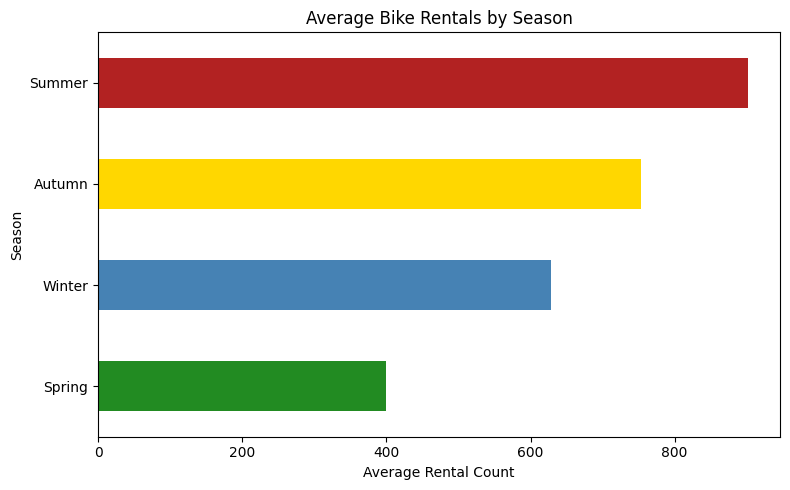

In [23]:
# Calculate average rental count by season
season_avg = bike_cleaned.groupby("season")["count"].mean().sort_values(ascending=True)

season_colours = {
    "Summer": "firebrick",
    "Autumn": "gold",
    "Winter": "steelblue",
    "Spring": "forestgreen"
}

bar_colours = [season_colours[season] for season in season_avg.index]

plt.figure(figsize=(8, 5))
ax = season_avg.plot(kind="barh", color=bar_colours)

plt.title("Average Bike Rentals by Season")
plt.xlabel("Average Rental Count")
plt.ylabel("Season")


plt.tight_layout()
plt.show()

### 7.2 Visualisation 2: Bike Rental Distribution by Weather Condition

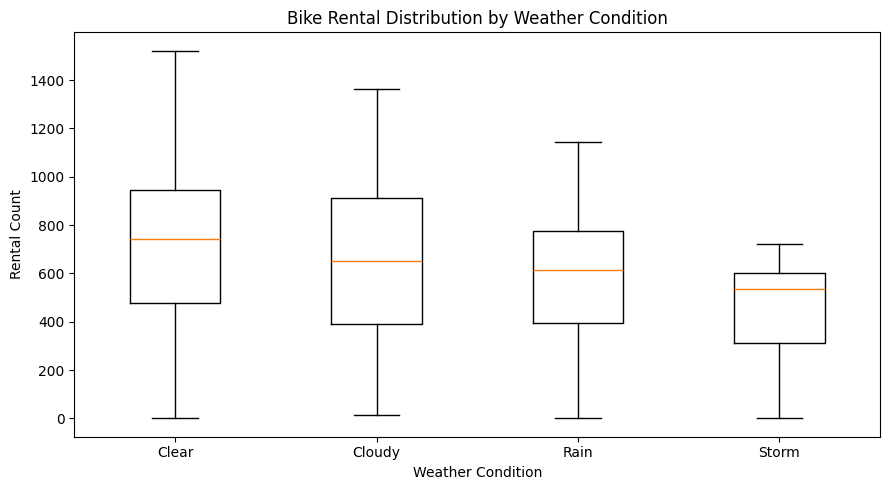

In [24]:
# Boxplot of rental count by weather condition
# This shows the distribution and variability of rentals under each weather condition

weather_order = ["Clear", "Cloudy", "Rain", "Storm"]

data_to_plot = [
    bike_cleaned[bike_cleaned["weather"] == weather]["count"]
    for weather in weather_order
]

plt.figure(figsize=(9, 5))
plt.boxplot(data_to_plot, tick_labels=weather_order)

plt.title("Bike Rental Distribution by Weather Condition")
plt.xlabel("Weather Condition")
plt.ylabel("Rental Count")
plt.tight_layout()
plt.show()

### 7.3 Visualisation 3: Temperature vs Rentals by Season

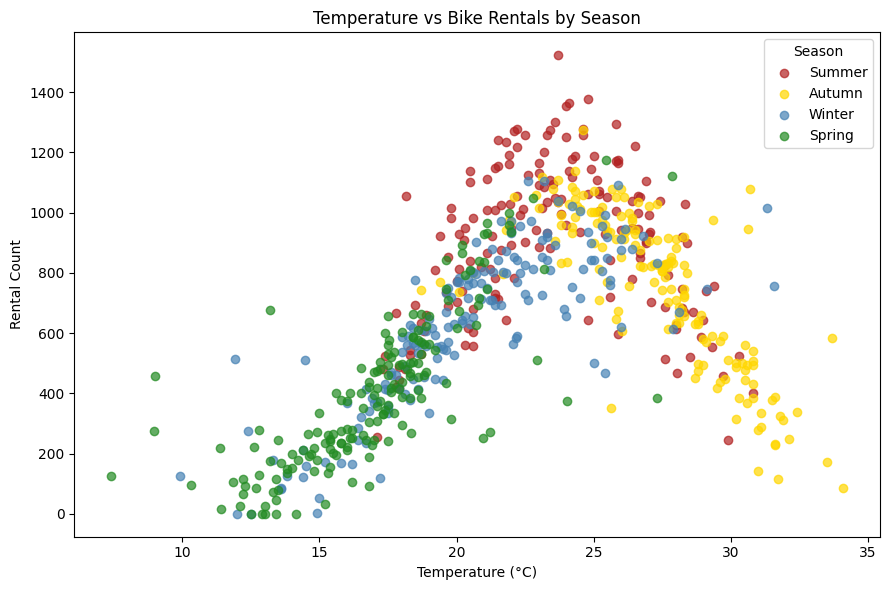

In [25]:
# Three attributes: temp, count, and season

season_colours = {
    "Summer": "firebrick",
    "Autumn": "gold",
    "Winter": "steelblue",
    "Spring": "forestgreen"
}

plt.figure(figsize=(9, 6))

for season, colour in season_colours.items():
    season_data = bike_cleaned[bike_cleaned["season"] == season]
    plt.scatter(
        season_data["temp"],
        season_data["count"],
        label=season,
        alpha=0.7,
        color=colour
    )

plt.title("Temperature vs Bike Rentals by Season")
plt.xlabel("Temperature (°C)")
plt.ylabel("Rental Count")
plt.legend(title="Season")
plt.tight_layout()
plt.show()

### 7.4 Visualisation 4: Bike Rental Demand Over Time

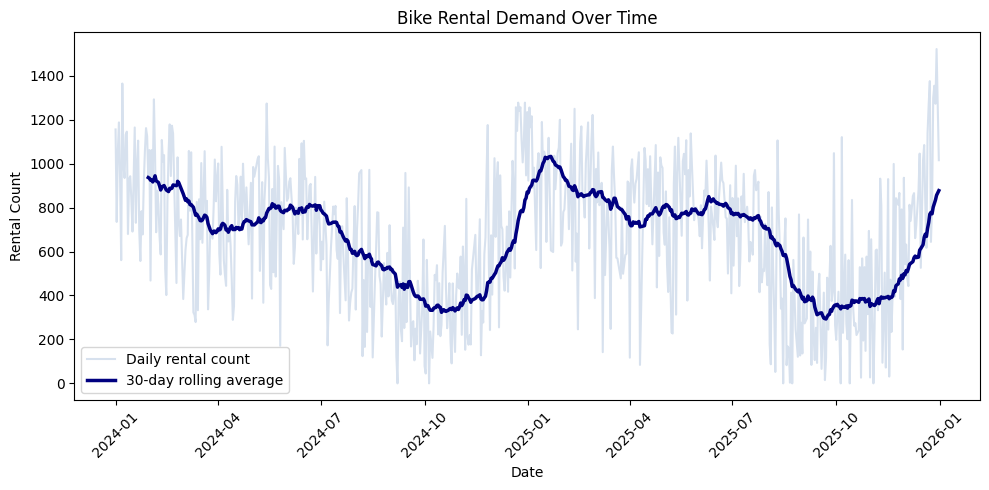

In [26]:
# Rental demand over time with rolling average
# Rolling average helps show the general trend more clearly

bike_time = bike_cleaned.sort_values("date").copy()

# Calculate 30-day rolling average
bike_time["rolling_30_day_avg"] = bike_time["count"].rolling(window=30).mean()

plt.figure(figsize=(10, 5))

# Daily demand
plt.plot(
    bike_time["date"],
    bike_time["count"],
    color="lightsteelblue",
    alpha=0.5,
    label="Daily rental count"
)

# Smoothed trend
plt.plot(
    bike_time["date"],
    bike_time["rolling_30_day_avg"],
    color="navy",
    linewidth=2.5,
    label="30-day rolling average"
)

plt.title("Bike Rental Demand Over Time")
plt.xlabel("Date")
plt.ylabel("Rental Count")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

## 8. Model Preparation

In [27]:
# Prepare modelling dataset
model_data = bike_cleaned.copy()

# Create a simple date-based feature as it may help the model capture seasonal/time-based demand patterns
model_data["month"] = model_data["date"].dt.month

# Target variable
y = model_data["count"]

# Features: remove target and non-model columns
# date is removed because raw datetime cannot be used directly in this model
# date_original is removed because it is a text version of the date
X = model_data.drop(columns=["count", "date", "date_original"])

# Convert categorical variables into dummy variables
X = pd.get_dummies(
    X,
    columns=["season", "weather"],
    drop_first=True
)

# Convert boolean columns to integers for cleaner modelling output
bool_columns = X.select_dtypes(include=["bool"]).columns
X[bool_columns] = X[bool_columns].astype(int)

# Safety check: all model features should now be numeric
non_numeric_columns = X.select_dtypes(exclude=[np.number]).columns

print("Feature columns:")
print(X.columns)

print("\nNon-numeric columns in X:")
print(list(non_numeric_columns))

print("\nMissing values in X:", X.isnull().sum().sum())
print("Missing values in y:", y.isnull().sum())

print("\nFeature dataset shape:", X.shape)
print("Target shape:", y.shape)

# Display first few rows of the final modelling dataset
X.head()

Feature columns:
Index(['holiday', 'workingday', 'temp', 'atemp', 'humidity', 'windspeed',
       'month', 'season_Spring', 'season_Summer', 'season_Winter',
       'weather_Cloudy', 'weather_Rain', 'weather_Storm'],
      dtype='str')

Non-numeric columns in X:
[]

Missing values in X: 0
Missing values in y: 0

Feature dataset shape: (671, 13)
Target shape: (671,)


,holiday,workingday,temp,atemp,humidity,windspeed,month,season_Spring,season_Summer,season_Winter,weather_Cloudy,weather_Rain,weather_Storm
0,1,0,21.5,21.6,68.8,11.9,1,0,1,0,1,0,0
1,1,0,19.6,18.7,60.1,11.8,1,0,1,0,0,0,0
2,1,0,22.2,24.3,84.5,15.7,1,0,1,0,0,1,0
3,1,0,25.0,22.4,73.1,18.4,1,0,1,0,1,0,0
4,1,0,20.1,20.5,66.4,4.9,1,0,1,0,0,0,0


## 9. Train-Test Split

In [28]:
# Split data into 70% training and 30% testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (469, 13)
Testing set size: (202, 13)


## 10. Main Prediction Model: Random Forest Regressor

Although the task sheet specifies only one regression model required, two regression models were developed to support the required reflection on the trade-off between accuracy and interpretability. Random Forest Regressor was used as the primary predictive model, while Linear Regression served as a baseline because it is simple and easier to interpret.

In [29]:
# Train Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

# Make predictions on the unseen test set
rf_predictions = rf_model.predict(X_test)

# Create a small comparison table of actual and predicted values
rf_results = pd.DataFrame({
    "Actual count": y_test.values,
    "Predicted count": rf_predictions
})

# Round predicted values for cleaner display
rf_results["Predicted count"] = rf_results["Predicted count"].round(2)

print("Random Forest model trained successfully.")
print("Number of test predictions made:", len(rf_predictions))

rf_results.head(10)

Random Forest model trained successfully.
Number of test predictions made: 202


,Actual count,Predicted count
0,598.0,716.65
1,933.0,907.84
2,854.0,821.24
3,792.0,796.01
4,456.0,427.46
5,1036.0,1078.19
6,674.0,779.52
7,803.0,790.83
8,758.0,697.27
9,819.0,802.66


## 11. Baseline Model: Linear Regression

In [30]:
# Train Linear Regression model
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# Make predictions on the unseen test set
linear_predictions = linear_model.predict(X_test)

# Create a small comparison table of actual and predicted values
linear_results = pd.DataFrame({
    "Actual count": y_test.values,
    "Predicted count": linear_predictions
})

# Round predicted values for cleaner display
linear_results["Predicted count"] = linear_results["Predicted count"].round(2)

print("Linear Regression model trained successfully.")
print("Number of test predictions made:", len(linear_predictions))

linear_results.head(10)

Linear Regression model trained successfully.
Number of test predictions made: 202


,Actual count,Predicted count
0,598.0,605.16
1,933.0,810.85
2,854.0,657.91
3,792.0,434.71
4,456.0,272.62
5,1036.0,899.47
6,674.0,411.01
7,803.0,620.61
8,758.0,667.09
9,819.0,764.58


## 12. Feature Importance of the Main Random Forest Model

### 12.1 Random Forest Feature Importance Table

In [31]:
# Random Forest feature importance
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(by="Importance", ascending=False)

display(feature_importance)

,Feature,Importance
2,temp,0.745116
3,atemp,0.099480
4,humidity,0.030049
5,windspeed,0.021114
6,month,0.020425
12,weather_Storm,0.016432
11,weather_Rain,0.015425
1,workingday,0.014472
8,season_Summer,0.014342
0,holiday,0.011576


### 12.2 Top 10 Feature Importance Plot for Random Forest

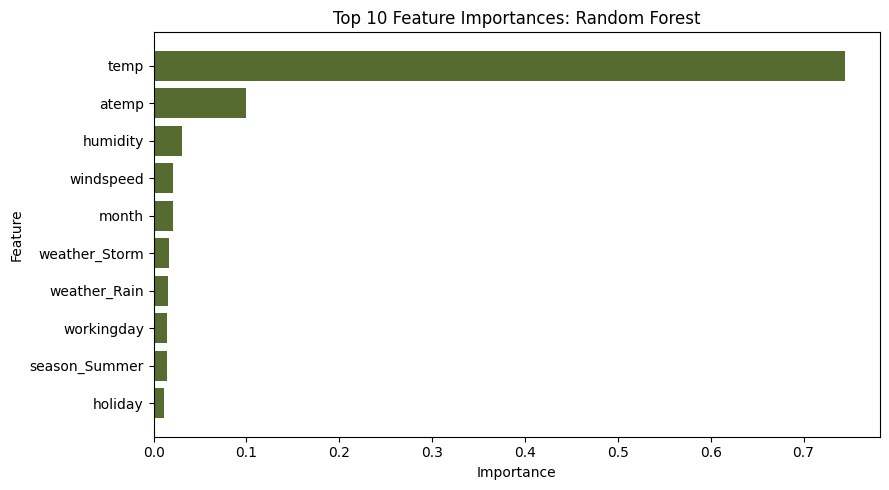

In [32]:
# Plot top feature importance values
top_features = feature_importance.head(10)

plt.figure(figsize=(9, 5))
plt.barh(top_features["Feature"], top_features["Importance"], color="darkolivegreen")

plt.title("Top 10 Feature Importances: Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 13. Models Evaluatuion and Comparison Based on RMSE, MAE and R²

Even so, the task sheet asks for only one model being evaluated using at least two metrics, I also evaluated both of the models developed on the same test set using RMSE, MAE and R². This allowed me to support the required discussion on the accuracy-interpretability trade-off in the written report. Thus, by comparing RMSE, MAE, and R², I could weigh the differences in predictive performance against those in model interpretability.

### 13.1 Evaluation of the Main and Baseline Models

In [33]:
# Evaluate Random Forest using RMSE, MAE and R²
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_r2 = r2_score(y_test, rf_predictions)

# Evaluate Linear Regression using RMSE, MAE and R²
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_predictions))
linear_mae = mean_absolute_error(y_test, linear_predictions)
linear_r2 = r2_score(y_test, linear_predictions)

### 13.2 Comparison of the Main and Baseline Models

In [34]:
# Compare model performance using regression metrics
# R² (%) shows R² expressed as a percentage for easier interpretation
# The best model is selected based on the lowest RMSE

model_results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "RMSE": [linear_rmse, rf_rmse],
    "MAE": [linear_mae, rf_mae],
    "R²": [linear_r2, rf_r2],
    "R² (%)": [linear_r2 * 100, rf_r2 * 100]
})

model_results["RMSE"] = model_results["RMSE"].round(2)
model_results["MAE"] = model_results["MAE"].round(2)
model_results["R²"] = model_results["R²"].round(3)
model_results["R² (%)"] = model_results["R² (%)"].round(2)

display(model_results)

best_model = model_results.sort_values(by="RMSE").iloc[0]

print("Best performing model based on RMSE:")
print("Model:", best_model["Model"])
print("RMSE:", best_model["RMSE"])
print("MAE:", best_model["MAE"])
print("R²:", best_model["R²"])
print("R² (%):", best_model["R² (%)"])

,Model,RMSE,MAE,R²,R² (%)
0,Linear Regression,229.47,185.09,0.473,47.26
1,Random Forest,113.60,87.57,0.871,87.07


Best performing model based on RMSE:
Model: Random Forest
RMSE: 113.6
MAE: 87.57
R²: 0.871
R² (%): 87.07
